## dockq score 비교 

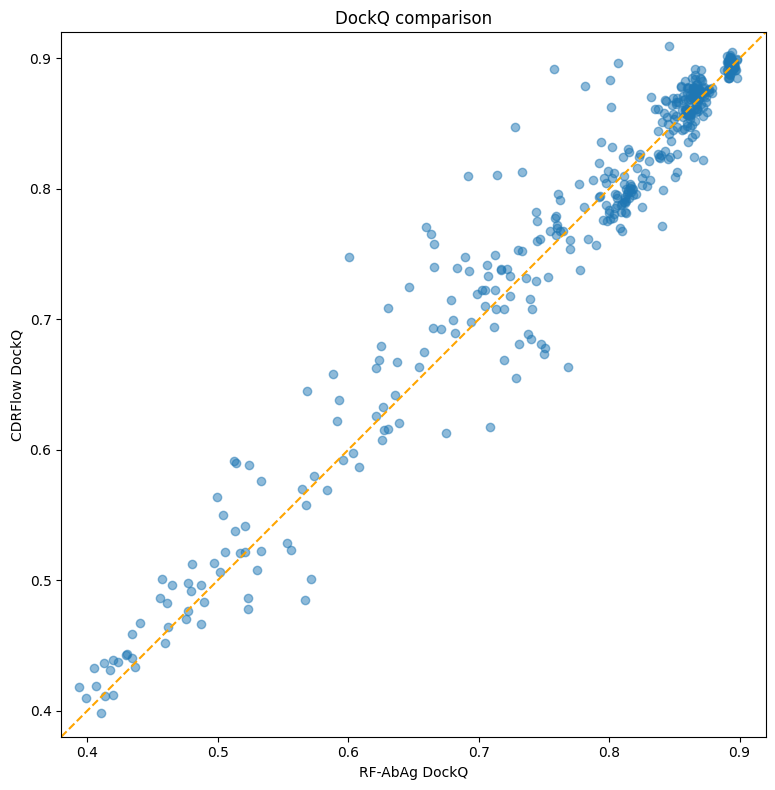

In [ ]:
import os 
import json 
import numpy as np 

kkh_dir = '/home/psh/BioBetter/kkh_benchmark/chothia'
my_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/kkh_wo_perturb'

kkh_dockqs = []
my_dockqs = []
for pdb_sample_id in os.listdir(my_dir):
    if 'config' in pdb_sample_id:
        continue
    pdb_id = '_'.join(pdb_sample_id.split('_')[:4])
    sample_id = '_'.join(pdb_sample_id.split('_')[4:])
    kkh_dockq_file = os.path.join(kkh_dir, pdb_id, sample_id + '.pdb_dockq.json')
    
    with open(kkh_dockq_file, 'r') as f:
        kkh_dockq = json.load(f)['GlobalDockQ']
    
    sample_dockqs_temp = []
    for subsample in os.listdir(os.path.join(my_dir, pdb_sample_id)):
        my_dockq_file = os.path.join(my_dir, pdb_sample_id, subsample, 'dockq.json')
    
        if not os.path.exists(my_dockq_file):
            continue
        with open(my_dockq_file, 'r') as f:
            my_dockq = json.load(f)['GlobalDockQ']
            print(f"{pdb_sample_id}: {my_dockq - kkh_dockq}")
            sample_dockqs_temp.append(my_dockq)
    if not os.path.exists(my_dockq_file):
        continue
    my_dockqs.append(np.quantile(sample_dockqs_temp, 1.0))
    kkh_dockqs.append(kkh_dockq)

import matplotlib.pyplot as plt

# Scatter plot with equal axis scale and y = x line
plt.figure(figsize=(8, 8))
plt.scatter(kkh_dockqs, my_dockqs, alpha=0.5)

# determine common limits
all_vals = kkh_dockqs + my_dockqs
vmin, vmax = min(all_vals), max(all_vals)

# y = x line
plt.plot([0.35, 0.92], [0.35, 0.92], linestyle='--', c='orange')

# equal axis scaling
plt.xlim(vmin, vmax)
plt.ylim(vmin, vmax)
plt.gca().set_aspect('equal', adjustable='box')

plt.xlabel("RF-AbAg DockQ")
plt.ylabel("CDRFlow DockQ")
plt.title("DockQ comparison")
plt.xlim((0.38, 0.92))
plt.ylim((0.38, 0.92))
plt.tight_layout()
plt.show()


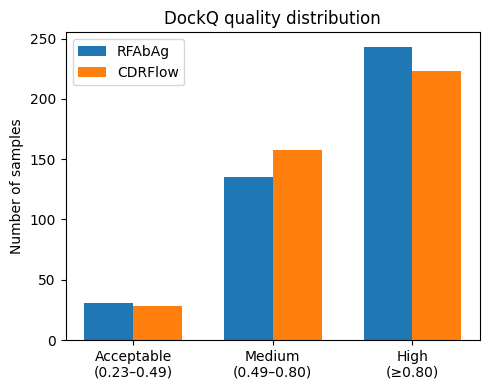

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays
kkh = np.array(kkh_dockqs)
my = np.array(my_dockqs)

# DockQ thresholds
bins = [(0.23, 0.49), (0.49, 0.80), (0.80, np.inf)]
labels = [
    "Acceptable\n(0.23–0.49)",
    "Medium\n(0.49–0.80)",
    "High\n(≥0.80)"
]

def count_by_bins(values, bins):
    return [
        np.sum((values >= low) & (values < high))
        for low, high in bins
    ]

kkh_counts = count_by_bins(kkh, bins)
my_counts = count_by_bins(my, bins)

# Bar positions
x = np.arange(len(labels))
width = 0.35

# Plot
plt.figure(figsize=(5, 4))
plt.bar(x - width/2, kkh_counts, width, label="RFAbAg")
plt.bar(x + width/2, my_counts, width, label="CDRFlow")

plt.xticks(x, labels)
plt.ylabel("Number of samples")
plt.title("DockQ quality distribution")
plt.legend()
plt.tight_layout()
plt.show()
